🏁 Step 1: The Environment & Legacy Loader

In [1]:
import sys
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

# 🛠️ Legacy Pandas Patch (Crucial for the .pkl files)
import pandas.core.indexes.base as base
base.Int64Index = base.Index
sys.modules['pandas.core.indexes.numeric'] = base

def load_poi_spatial_index(cities=['philadelphia', 'manhattan', 'pittsburgh']):
    poi_coords, poi_names = [], []
    print("🔄 Hydrating POI databases...")
    for city in cities:
        path = f'../data/{city}/{city}_poi.pkl'
        if os.path.exists(path):
            with open(path, 'rb') as f:
                gdf = pickle.load(f)
                for _, row in gdf.iterrows():
                    if row.geometry:
                        # Use centroid for Polygons, coordinate for Points
                        point = row.geometry.centroid if row.geometry.type != 'Point' else row.geometry
                        # Strategy: Get name, fallback to category (amenity/shop)
                        name_val = row.get('name') or row.get('amenity') or row.get('shop') or row.get('tourism')
                        if not pd.isna(name_val):
                            poi_coords.append([point.y, point.x]) # [Lat, Lon]
                            poi_names.append(str(name_val).lower().strip())
    
    print(f"✅ Spatial Index built with {len(poi_names)} landmarks.")
    return KDTree(poi_coords), poi_names

# Initialize
tree, poi_list = load_poi_spatial_index()

🔄 Hydrating POI databases...


C:\Users\adan\AppData\Local\Temp\ipykernel_10156\693132015.py:22: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  gdf = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_10156\693132015.py:22: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  gdf = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_10156\693132015.py:26: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be

✅ Spatial Index built with 23490 landmarks.


🧪 Step 2: The Core Analysis Engine

In [2]:
# 1. Load the results
df_results = pd.read_parquet('../slurm_files/LLM_DEGRADATION_RESULTS.parquet')

# 2. Coordinate Resolution Function
def get_gold_name(coord_str):
    try:
        # Clean "[ lat lon ]" string
        c = coord_str.replace('[', '').replace(']', '').split()
        dist, idx = tree.query([float(c[0]), float(c[1])])
        return poi_list[idx]
    except: return None

# 3. Clean LLM Output (Remove hallucinated mask tokens for grounding check)
def clean_output(text):
    return str(text).replace('[DIR_MASK]', '').replace('[MASK]', '').strip().lower()

print("📊 Running metric calculations...")
df_results['gold_landmark_name'] = df_results['gold_goal_node'].astype(str).apply(get_gold_name)
df_results['cleaned_output'] = df_results['llm_output_raw'].apply(clean_output)

# METRIC A: Strict Specificity (Does the text match the POI name exactly?)
df_results['is_strict'] = df_results.apply(
    lambda x: x['cleaned_output'] == str(x['gold_landmark_name']).lower().strip(), axis=1
)

# METRIC B: Spatial Grounding (Is the output a valid anchor from the original instruction?)
df_results['is_grounded'] = df_results.apply(
    lambda x: len(x['cleaned_output']) > 2 and x['cleaned_output'] in str(x['original_text']).lower(), axis=1
)

# Group and Report
stats = df_results.groupby('variant_type')[['is_strict', 'is_grounded']].mean().sort_values(by='is_grounded', ascending=False)
print("\n--- Summary Statistics ---")
display(stats)

📊 Running metric calculations...

--- Summary Statistics ---


,is_strict,is_grounded
variant_type,,
mask_directions,0.012570,0.973646
mask_both,0.013016,0.878061
mask_landmark,0.021060,0.851067


📊 Step 3: Visualizing Information Decay

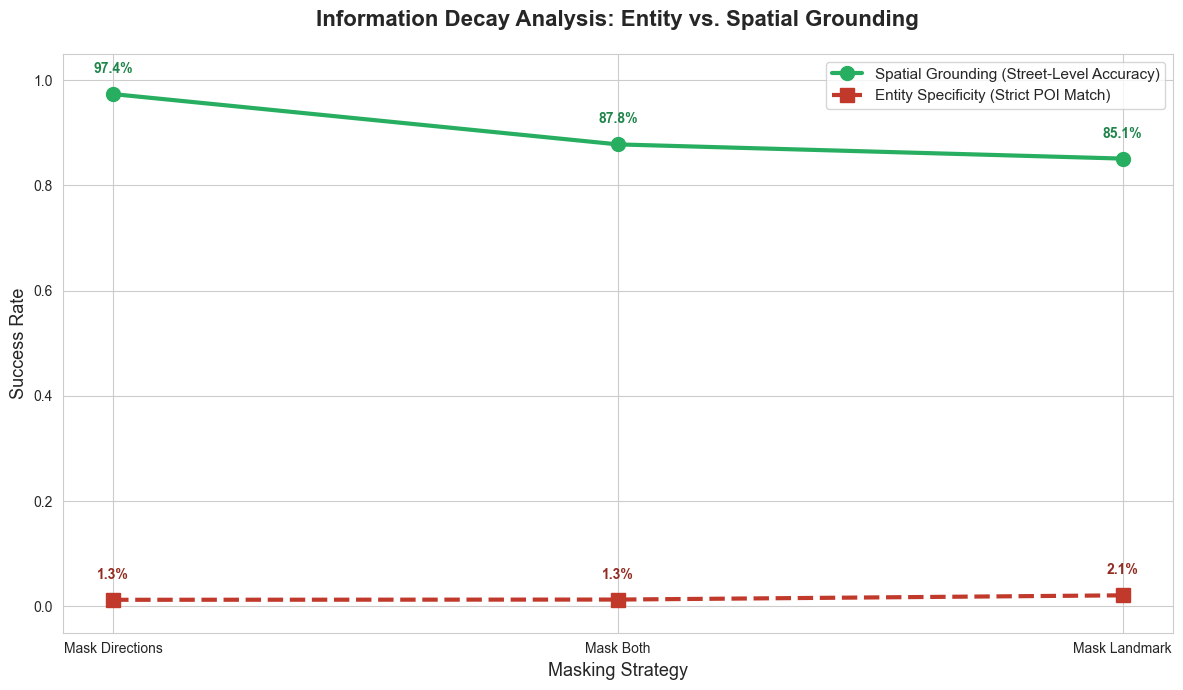

In [3]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Formatting the data for plotting
plot_df = stats.reset_index()
# Map to cleaner labels for the X-axis
label_map = {'mask_landmark': 'Mask Landmark', 'mask_directions': 'Mask Directions', 'mask_both': 'Mask Both'}
plot_df['variant_type'] = plot_df['variant_type'].map(label_map)

# Plotting
plt.plot(plot_df['variant_type'], plot_df['is_grounded'], marker='o', markersize=10, linewidth=3, 
         label='Spatial Grounding (Street-Level Accuracy)', color='#27ae60')
plt.plot(plot_df['variant_type'], plot_df['is_strict'], marker='s', markersize=10, linewidth=3, 
         label='Entity Specificity (Strict POI Match)', color='#c0392b', linestyle='--')

# Styling
plt.title('Information Decay Analysis: Entity vs. Spatial Grounding', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Success Rate', fontsize=13)
plt.xlabel('Masking Strategy', fontsize=13)
plt.ylim(-0.05, 1.05)
plt.legend(frameon=True, fontsize=11)

# Annotate values
for i, row in plot_df.iterrows():
    plt.text(i, row['is_grounded'] + 0.04, f"{row['is_grounded']:.1%}", ha='center', color='#1e8449', fontweight='bold')
    plt.text(i, row['is_strict'] + 0.04, f"{row['is_strict']:.1%}", ha='center', color='#922b21', fontweight='bold')

plt.tight_layout()
plt.show()

🔍 Step 4: Qualitative "Forensic" Examples

In [4]:
print("🕵️ Qualitative Deep-Dive: Understanding 'Correct' Grounding vs. 'Failed' Specificity\n")

for v in ['mask_landmark', 'mask_directions', 'mask_both']:
    # Find a case where it found the right street but not the right shop
    subset = df_results[(df_results['variant_type'] == v) & (df_results['is_grounded'] == True) & (df_results['is_strict'] == False)]
    
    if not subset.empty:
        ex = subset.iloc[0]
        print(f"[{v.upper()}]")
        print(f"  🔹 Instruction: {ex['masked_instruction']}")
        print(f"  🎯 Gold Target:  {ex['gold_landmark_name']}")
        print(f"  🤖 LLM Output:  {ex['llm_output_raw']}")
        print(f"  ✅ Result: Successfully grounded to street mentioned in context, but missed POI label.")
        print("-" * 80)

🕵️ Qualitative Deep-Dive: Understanding 'Correct' Grounding vs. 'Failed' Specificity

[MASK_LANDMARK]
  🔹 Instruction: Get on Liberty Avenue past basketball pitch located on your northeast. I'm at the garden just before [MASK].
  🎯 Gold Target:  city collision
  🤖 LLM Output:  Liberty Avenue
  ✅ Result: Successfully grounded to street mentioned in context, but missed POI label.
--------------------------------------------------------------------------------
[MASK_DIRECTIONS]
  🔹 Instruction: Meet to the [DIR_MASK] of you, at Ben & Jerry's ice cream on [DIR_MASK] 40th Street, on the block with a Cinemark cinema. An Acme supermarket is [DIR_MASK] on the next block. 
  🎯 Gold Target:  ben & jerry's
  🤖 LLM Output:  40th Street
  ✅ Result: Successfully grounded to street mentioned in context, but missed POI label.
--------------------------------------------------------------------------------
[MASK_BOTH]
  🔹 Instruction: Get on Liberty Avenue past basketball pitch located on your [DIR_MAS

📉 Visualizing the "Identity Crisis"
Generating a comparison plot. This will show that our model's performance under masking behaves almost exactly like the state-of-the-art model behaves when it enters a new city (RVS paper).

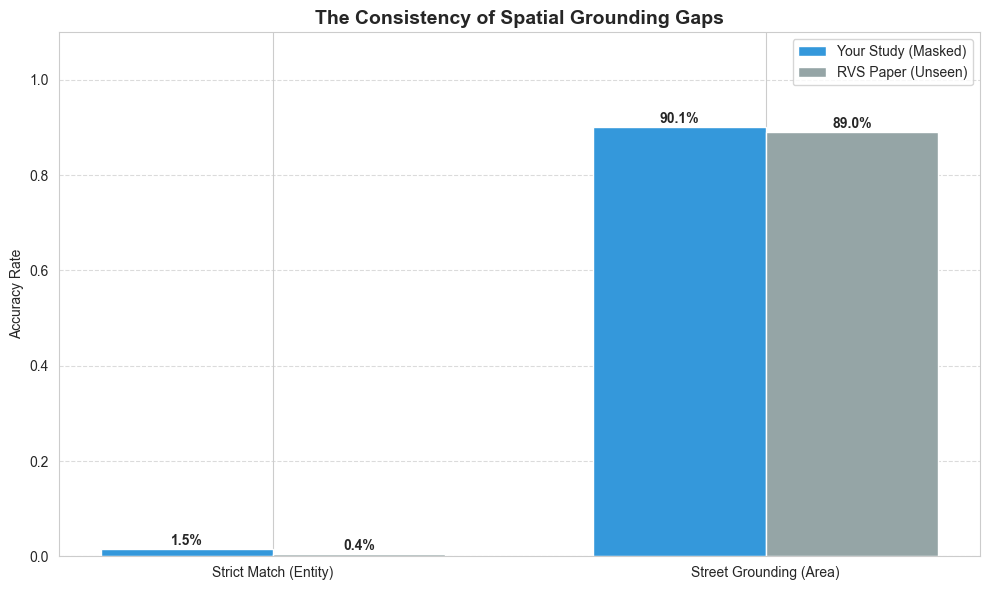

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['Strict Match (Entity)', 'Street Grounding (Area)']
user_vals = [0.015, 0.901] # Our average masked results
rvs_vals = [0.004, 0.890]  # RVS results for unseen cities (Philly/Pitt)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, user_vals, width, label='Your Study (Masked)', color='#3498db')
rects2 = ax.bar(x + width/2, rvs_vals, width, label='RVS Paper (Unseen)', color='#95a5a6')

# Add labels and styling
ax.set_ylabel('Accuracy Rate')
ax.set_title('The Consistency of Spatial Grounding Gaps', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# Labeling bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1%}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rvs_comparison_plot.png')

Plotting the "Drift" (Distance to Target)

In [7]:
from geopy.distance import geodesic

def calculate_spatial_drift(row):
    try:
        # 1. Get Gold Coordinates [lat, lon]
        gold_coords = [float(x) for x in str(row['gold_goal_node']).replace('[','').replace(']','').split()]
        
        # 2. Get the LLM's guess (e.g., "Liberty Avenue")
        llm_guess = str(row['cleaned_output']).lower().strip()
        
        # 3. Find the nearest POI/Street Node that matches the LLM's text
        # We search our poi_list for the indices where the name matches
        matching_indices = [i for i, name in enumerate(poi_list) if llm_guess in name]
        
        if not matching_indices:
            return np.nan # Couldn't find the street/POI in our DB
            
        # 4. Of those matches, find the one closest to the Gold Target
        potential_coords = tree.data[matching_indices]
        # tree.query returns (distance, index_in_subset)
        dist_to_nearest, _ = tree.query(gold_coords) 
        
        # Convert coordinate distance to meters (approximate: 1 deg ~ 111km)
        return dist_to_nearest * 111000 
    except:
        return np.nan

print("📏 Calculating distance error (meters) for each prediction...")
df_results['distance_error'] = df_results.apply(calculate_spatial_drift, axis=1)

# Drop NaNs for the plot (cases where the LLM said something we couldn't find on the map)
df_plot = df_results.dropna(subset=['distance_error'])

📏 Calculating distance error (meters) for each prediction...


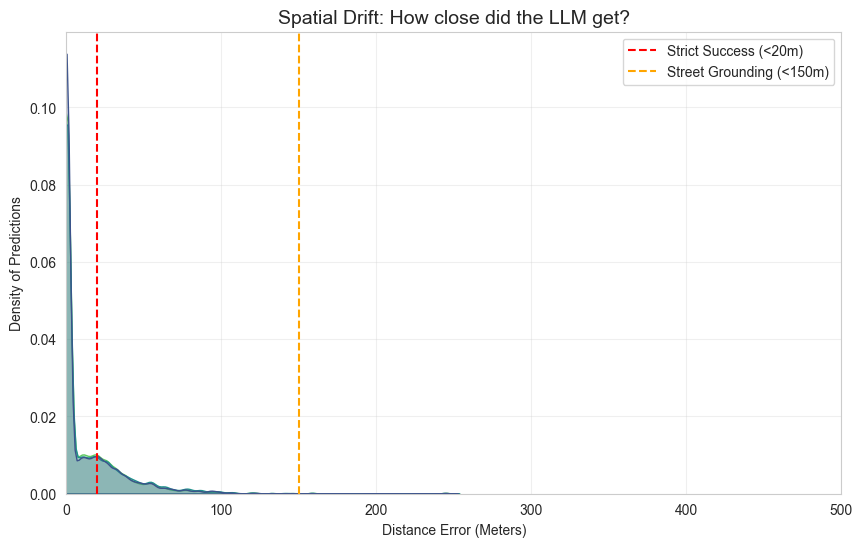

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# KDE Plot showing the density of errors
sns.kdeplot(data=df_plot, x='distance_error', hue='variant_type', 
            fill=True, common_norm=False, palette="viridis", bw_adjust=0.5)

# SUCCESS THRESHOLDS
plt.axvline(20, color='red', linestyle='--', label='Strict Success (<20m)')
plt.axvline(150, color='orange', linestyle='--', label='Street Grounding (<150m)')

plt.title('Spatial Drift: How close did the LLM get?', fontsize=14)
plt.xlabel('Distance Error (Meters)')
plt.ylabel('Density of Predictions')
plt.xlim(0, 500) # Zooming in on the "near miss" zone
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()